# Del 3- Model Selection

In [41]:
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import f1_score
from itertools import product
import numpy as np
import nbimporter
import DecTree
from DecTree import DecisionTree
import random_forest
from random_forest import RandomForest

#Fra oppgaveteksten 
seed= 0
np.random.seed(seed) #For å kunne reprodusere resultatene våre

data = np.genfromtxt("letters.csv", delimiter=",", dtype=float, names=True)
feature_names = list(data.dtype.names[:-1])
target_name = data.dtype.names[-1]
X = np.array([data[feature] for feature in feature_names]).T
y = data[target_name].astype(int)


print(f"Feature columns names: {feature_names}")
print(f"Target column name: {target_name}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split data 60% train 20% test 20% val

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=seed
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=seed 
)


Feature columns names: ['xbox', 'ybox', 'width', 'high', 'onpix', 'xbar', 'ybar', 'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br', 'xege', 'xegvy', 'yege', 'yegvx']
Target column name: label
X shape: (2000, 16)
y shape: (2000,)


## Cross Validation

In [42]:
#LAger kfold (deler data i k like deler som deretter blir trent opp og evaluert)
#Bruker f1score for å måle balansen mellom precision og recall 
def cross_validation(model, X: np.array, y: np.array, k: int = 5):
    kf = KFold(n_splits = k, shuffle=True, random_state=seed)
    scores = []

    for train_idx, val_idx in kf.split(X):
        X_train_kfold, X_val_kfold = X[train_idx], X[val_idx]
        y_train_kfold, y_val_kfold = y[train_idx], y[val_idx]

        model.fit(X_train_kfold, y_train_kfold)
        y_pred = model.predict(X_val_kfold)

        #macro gir like mye vekt til A-F
        cross_val_score = f1_score(y_val_kfold, y_pred, average="macro")
        scores.append(cross_val_score)

    return scores

### Hyperparameter tuning for Decision Tree

In [53]:
max_depth = [None, 5, 10, 15, 20, 30]
max_features = [ 'sqrt', 'log2', None]
criterion = ["entropy", "gini"]

hyper_parameters = list(product(max_depth, max_features, criterion))
val_scores = []

for depth, features, crit in hyper_parameters:
    DT = DecisionTree(max_depth=depth, max_features=features, criterion=crit)
    cross_val_score = cross_validation(DT, X_train, y_train)
    avg_score = np.mean(cross_val_score)
    val_scores.append(avg_score)

best_score_idx = np.argmax(val_scores)
best_depth, best_feature, best_crit = hyper_parameters[best_score_idx]


print('The best depth is: ', best_depth)
print('The best feature is: ', best_feature)
print('Best criterion: ', best_crit)
print('Accuracy: ', val_scores[best_score_idx])

The best depth is:  None
The best feature is:  sqrt
Best criterion:  gini
Accuracy:  0.8960741144025194


### Hyperparameter tuning for Random Forest

In [ ]:
max_depth = [None, 5, 10, 15, 20, 30]
max_features = [ 'sqrt', 'log2', None]
criterion = ["entropy", "gini"]
n_estimators = [3, 7, 10, 15]

RF_hyp_parameters = list (product(max_depth, max_features, criterion, n_estimators))
RF_val_scores = []

for depth, features, crit, n_est in RF_hyp_parameters:
    RF = RandomForest(n_estimators=n_est, max_depth=depth, 
                      criterion=crit, max_features=features)
    RF_cross_val_scores = cross_validation(RF, X_train, y_train)
    RF_avg_score = np.mean(RF_cross_val_scores)
    RF_val_scores.append(RF_avg_score)

RF_best_score = np.argmax(RF_val_scores)
RF_best_depth, RF_best_feature, RF_best_crit, RF_best_n_estimator = RF_hyp_parameters[RF_best_score]

print('The best depth is: ', RF_best_depth)
print('The best feature is: ', RF_best_feature)
print('Best criterion: ', RF_best_crit)
print("Best n_estimator: ", RF_best_n_estimator)
print('Accuracy: ', RF_val_scores[RF_best_score])



The best depth is:  10
The best feature is:  log2
Best criterion:  entropy
Best n_estimator:  15
Accuracy:  0.9416243510751265


### Sklearn Decision Tree

In [ ]:
##Same procedure as our own DT, we now use sklearns DT
import sklearn
from sklearn.tree import DecisionTreeClassifier as DTC #Import with new name to not get cofused 

max_depth = [None, 5, 10, 15, 20, 30]
max_features = ['sqrt', 'log2', None]
criterion = ['entropy', 'gini']
n_estimators = [3, 7, 10, 15]

seed = 0
np.random.seed(seed)

dtc_hyper_parameters = list(product(max_depth, max_features, criterion))
dtc_val_scores = []

for depth, features, criterion in dtc_hyper_parameters:
    dtc = DTC(max_depth = depth, criterion = criterion, max_features = features, random_state = seed)
    dtc_val_scores = cross_validation(dtc, X_train, y_train)
    dtc_avg_score = np.mean(dtc_val_scores)
    dtc_val_scores.append(dtc_avg_score)

dtc_best_score_idx = np.argmax(dtc_val_scores)

dtc_best_depth, dtc_best_feature, dtc_best_crit = dtc_hyper_parameters[dtc_best_score_idx]




print('The best depth is: ', dtc_best_depth)     
print('The best feature: ', dtc_best_feature) 
print('Best criterion: ', dtc_best_crit)  
print('Accurancy: ', dtc_val_scores[dtc_best_score_idx])

The best depth is:  None
The best feature:  log2
Best criterion:  entropy
Accurancy:  0.9123469236480269


### Sklearn Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier as RFC #New name

max_depth = [None, 5, 10, 15, 20, 30]
max_features = ['sqrt', 'log2', None]
criterion = ['entropy', 'gini']
n_estimators = [3, 7, 10, 15]

seed = 0
np.random.seed(seed)

rfc_hyper_parameters = list(product(n_estimators, criterion, max_depth, max_features))
rfc_val_scores = []

for n_estimators, criterion, depth, feature in rfc_hyper_parameters:
    rfc = RFC(n_estimators = n_estimators, criterion = criterion, max_depth = depth, max_features = feature)
    rfc_cross_val = cross_validation(rfc, X_train, y_train)
    rfc_avg_score = np.mean(rfc_cross_val)
    rfc_val_scores.append(rfc_avg_score)

rfc_best_score_idx = np.argmax(rfc_val_scores)

rfc_best_n_estimator, rfc_best_crit, rfc_best_depth, rfc_best_feature = rfc_hyper_parameters[rfc_best_score_idx]



print('The best depth is: ', rfc_best_depth)
print('The best feature is: ', rfc_best_feature)
print('Best criterion: ', rfc_best_crit)
print("Best n_estimator: ", rfc_best_n_estimator)
print('Accurancy: ', rfc_val_scores[rfc_best_score_idx])

The best depth is:  30
The best feature is:  log2
Best criterion:  gini
Best n_estimator:  15
Accurancy:  0.9526604356967882


## Testing

### Our Decision Tree & Random Forest

In [ ]:
#Our Decision Tree
final_DT = DecisionTree(max_depth = best_depth, max_features = best_feature, criterion = best_crit)## now we use the best hyperparameters
final_DT.fit(X_train, y_train) ## trains our model on training data
DT_y_pred = final_DT.predict(X_test) ## now we finally use the unseen test data to actually test our model
final_DT_score = f1_score(y_test, DT_y_pred, average="macro")## scores predictions made on the unseen data
print('Accuracy of our Decision Tree: ', final_DT_score)

#Our Random Forest
final_RF = RandomForest(n_estimators = RF_best_n_estimator, max_depth = RF_best_depth, criterion = best_crit, max_features = best_feature)
final_RF.fit(X_train, y_train)
RF_y_pred = final_RF.predict(X_test)
final_RF_score = f1_score(y_test, RF_y_pred, average="macro")
print('Accuracy of our Random Forest: ', final_RF_score)

Accuracy of our Decision Tree:  0.9351963633884083
Accuracy of our Random Forest:  0.9402294328530298


### Sklearns Decision Tree & Random Forest

In [ ]:
final_dtc = DTC(max_depth = dtc_best_depth, criterion = dtc_best_crit, max_features =  dtc_best_feature, random_state = seed)
final_dtc.fit(X_train, y_train)
dtc_y_pred = final_dtc.predict(X_test)
final_dtc_score = f1_score(y_test, dtc_y_pred, average="macro")

print ('Accuracy of sklearn Decision Tree: ', final_dtc_score)

final_rfc = RFC(n_estimators = rfc_best_n_estimator, criterion = rfc_best_crit,  max_depth = rfc_best_depth, max_features = rfc_best_feature, random_state = seed)
final_rfc.fit(X_train, y_train)
rfc_y_pred = final_rfc.predict(X_test)
final_rfc_score = f1_score(y_test, rfc_y_pred, average="macro")

print('Accuracy of sklearn Random Forest: ',final_rfc_score)


Accuracy of sklearn Decision Tree:  0.9077191462337219
Accuracy of sklearn Random Forest:  0.9535226202289877


### Feature Importance

[11 14  6 15  8  7  9 13 10  0  1  4 12  3  5  2]


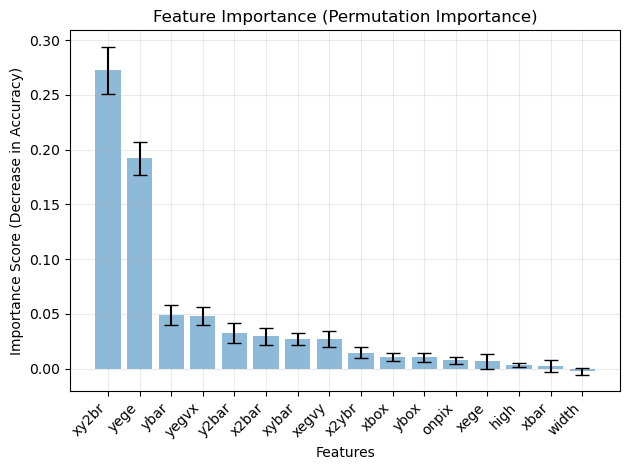

xy2br     : 0.2723 ± 0.0217
yege      : 0.1921 ± 0.0153
ybar      : 0.0493 ± 0.0093
yegvx     : 0.0480 ± 0.0082
y2bar     : 0.0324 ± 0.0090
x2bar     : 0.0297 ± 0.0079
xybar     : 0.0273 ± 0.0056
xegvy     : 0.0271 ± 0.0074
x2ybr     : 0.0146 ± 0.0050
xbox      : 0.0108 ± 0.0033
ybox      : 0.0103 ± 0.0039
onpix     : 0.0078 ± 0.0031
xege      : 0.0067 ± 0.0067
high      : 0.0033 ± 0.0021
xbar      : 0.0027 ± 0.0053
width     : -0.0025 ± 0.0029


(array([ 0.01075   ,  0.01033333, -0.0025    ,  0.00333333,  0.00775   ,
         0.00266667,  0.04925   ,  0.02966667,  0.03241667,  0.02733333,
         0.01458333,  0.27233333,  0.00666667,  0.02708333,  0.19208333,
         0.048     ]),
 array([0.00330088, 0.00385861, 0.00288675, 0.00207498, 0.00305164,
        0.0053203 , 0.009268  , 0.00787224, 0.00895552, 0.00558768,
        0.00500347, 0.02168845, 0.00665624, 0.0073904 , 0.01526275,
        0.00822598]),
 array([11, 14,  6, 15,  8,  7,  9, 13, 10,  0,  1,  4, 12,  3,  5,  2]))

In [52]:
#from sklearn.inspection import permutation_importance
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

#Kjører på sklearn sin RFC pga tid
def permutation_importance(
    model= final_rfc,
    X = X_test,
    y = y_test,
    metric = accuracy_score,
    n_repeats=30,
    random_state=seed):

    np.random.seed(seed)

    n_features= X.shape[1] #antall features
    baseline_preds = model.predict(X) #originale testdata
    baseline_score = metric(y, baseline_preds) #accuracy før permutasjoner
    importances = np.zeros((n_features, n_repeats)) #tom matrise der rad = ft, kol=gjentakelse


    for feat_idx in range (n_features):
        for repeat in range(n_repeats):
            X_permuted = X.copy()
            
            np.random.shuffle(X_permuted[: , feat_idx]) #tar kopi av X og stokker verdiene i ft nr

            permuted_predictions = model.predict(X_permuted)
            permuted_score = metric(y, permuted_predictions) #kjører modellen på permuttert data og finner accuracy etter stokking

            importance = baseline_score - permuted_score #regner ut hvor mye dårligere accuracien ble
            importances[feat_idx, repeat] = importance #lagrer i matrisen
    
    
    #regner gjen.snitt og standardavikk over de 30 gjentakelsene med axis=1 (behold en verdi per ft)
    importances_mean = np.mean(importances, axis=1)
    importances_std = np.std(importances, axis=1)

    return importances_mean, importances_std

#kjører funksjonen og får ut viktigheter + usikkerhet  
def perm_imp_analysis():
    importances_mean, importances_std = permutation_importance(
        model=final_rfc,
        X=X_test,
        y=y_test,
        metric=accuracy_score,
        n_repeats=30,
        random_state=seed
    )
#Figur
    plt.figure()
    indices = np.argsort(importances_mean)[::-1]
    print(indices)

    plt.bar(range(len(feature_names)),
        importances_mean[indices],
        yerr = importances_std[indices],
        capsize=5,
        alpha=0.5)
    plt.title('Feature Importance (Permutation Importance)')
    plt.xlabel('Features')
    plt.ylabel('Importance Score (Decrease in Accuracy)')

    plt.xticks(range(len(feature_names)),
               [feature_names[i] for i in indices],
               rotation=45, ha='right')
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
    for i in indices:
        print(f"{feature_names[i]:10s}: {importances_mean[i]:.4f} ± {importances_std[i]:.4f}")
    

    return importances_mean, importances_std, indices

# importances_mean, importances_std, indices = perm_imp_analysis()
perm_imp_analysis()

